In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from autorank import autorank, plot_stats, create_report

In [2]:
# ==============================================================================
# PAINEL DE CONTROLO - ALTERE AQUI OS SEUS PARÂMETROS
# ==============================================================================
METRICA_ESCOLHIDA = 'f1'    # Digite a métrica desejada: 'auc_roc', 'f1', etc.
SEQUENCIA_ESCOLHIDA = '50'       # Digite '10', '20', '30', '40', '50' ou 'TODAS'
# ==============================================================================

In [3]:
# 1. Lista dos seus arquivos de experimentos
arquivos_parquet = [
    'results/ai4i-all_experiments_results.parquet',
    'results/occupancy-all_experiments_results.parquet',
    'results/ozone-all_experiments_results.parquet',
    'results/cobot-all_experiments_results.parquet'
]

all_data = []

print(f"-> A carregar os arquivos e focar na métrica: {METRICA_ESCOLHIDA.upper()}")
for arquivo in arquivos_parquet:
    df = pd.read_parquet(arquivo)
    # Garante que as strings de configuração virem uma coluna
    df = df.reset_index()
    
    # Extrai o nome do dataset
    nome_dataset = arquivo.split('-')[0]
    df['dataset_origem'] = nome_dataset
    
    all_data.append(df)

df_completo = pd.concat(all_data, ignore_index=True)

# Verifica se a métrica escolhida existe nos dados
if METRICA_ESCOLHIDA not in df_completo.columns:
    print(f"\nERRO: A métrica '{METRICA_ESCOLHIDA}' não foi encontrada nas colunas do arquivo!")
    print("Colunas disponíveis:", df_completo.columns.tolist())
    exit()

-> A carregar os arquivos e focar na métrica: F1


In [4]:
# 2. Identificação da coluna de texto com as configurações
col_config = None
for col in df_completo.columns:
    if df_completo[col].astype(str).str.contains('rnn|hybrid|lstm|gru|Iteration', case=False).any():
        col_config = col
        break

if col_config is None:
    col_textos = df_completo.select_dtypes(include=['object']).columns
    col_config = col_textos[0] if len(col_textos) > 0 else df_completo.columns[0]

In [5]:
# 3. Funções de extração de texto
def extrair_modelo(texto):
    texto_str = str(texto).lower()
    if 'pure-lstm' in texto_str: return 'Pure-LSTM'
    elif 'pure-gru' in texto_str: return 'Pure-GRU'
    elif 'pure-rnn' in texto_str: return 'Pure-RNN'
    elif 'hybrid' in texto_str: return 'Hybrid'
    return 'Outros'

def extrair_iteracao(texto):
    match = re.search(r'Iteration-(\d+)', str(texto), re.IGNORECASE)
    return match.group(1) if match else '1'

def extrair_sequencia(texto):
    # Procura pelo padrão "SequenceLength-XX"
    match = re.search(r'SequenceLength-(\d+)', str(texto), re.IGNORECASE)
    return match.group(1) if match else 'Desconhecido'

df_completo['modelo_limpo'] = df_completo[col_config].apply(extrair_modelo)
df_completo['iteracao'] = df_completo[col_config].apply(extrair_iteracao)
df_completo['tamanho_sequencia'] = df_completo[col_config].apply(extrair_sequencia)

In [6]:
# 4. Filtro pela Sequência Escolhida
if SEQUENCIA_ESCOLHIDA.upper() != 'TODAS':
    df_completo = df_completo[df_completo['tamanho_sequencia'] == str(SEQUENCIA_ESCOLHIDA)]
    print(f"-> A filtrar apenas dados com SequenceLength = {SEQUENCIA_ESCOLHIDA}")
else:
    print("-> A analisar todas as sequências juntas.")

# Define a linha do teste
df_completo['chave_dataset'] = df_completo['dataset_origem'] + "rep" + df_completo['iteracao']

# Remove modelos não mapeados
df_completo = df_completo[df_completo['modelo_limpo'] != 'Outros']

-> A filtrar apenas dados com SequenceLength = 50


In [7]:
# 5. Criação da tabela pivô dinâmica
df_autorank = df_completo.pivot_table(
    index='chave_dataset',
    columns='modelo_limpo',
    values=METRICA_ESCOLHIDA,
    aggfunc='mean'
)

# Preenche buracos com a média para evitar perda de dados
df_autorank = df_autorank.fillna(df_autorank.mean())

print(f"\n-> Total de iterações válidas para o teste: {len(df_autorank)}")
print("-" * 60)


-> Total de iterações válidas para o teste: 40
------------------------------------------------------------


A executar teste estatístico (Métrica: f1 | Seq: 50)...
           meanrank    median       mad  ci_lower  ci_upper effect_size  \
Hybrid        3.975  0.119601  0.072295  0.028856  0.862827         0.0   
Pure-LSTM     2.975  0.301927  0.101587  0.154702  0.898918   -1.394833   
Pure-GRU      1.675  0.389401  0.104219  0.241873  0.938111   -2.028981   
Pure-RNN      1.375  0.375814  0.105145  0.262044  0.940205   -1.915297   

            magnitude effect_size_above magnitude_above  
Hybrid     negligible               0.0      negligible  
Pure-LSTM       large         -1.394833           large  
Pure-GRU        large         -0.573312          medium  
Pure-RNN        large          0.087545      negligible  

RELATÓRIO DO TESTE - Métrica: F1 | Seq: 50
The statistical analysis was conducted for 4 populations with 40 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations Hybrid 

<Figure size 1000x400 with 0 Axes>

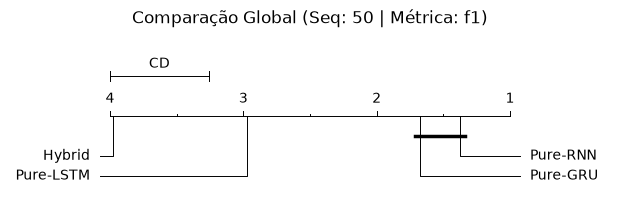

In [8]:
# 6. Execução do Teste Estatístico
if len(df_autorank) < 5:
    print(f"ERRO CRÍTICO: Menos de 5 amostras encontradas para a sequência {SEQUENCIA_ESCOLHIDA}.")
    print("Isso pode acontecer se esse tamanho de sequência não existir em todas as bases.")
else:
    print(f"A executar teste estatístico (Métrica: {METRICA_ESCOLHIDA} | Seq: {SEQUENCIA_ESCOLHIDA})...")
    resultado = autorank(df_autorank, alpha=0.05, verbose=False, order='descending')
    
    # Exibição dos Resultados
    print("\n" + "="*60)
    print(f"RELATÓRIO DO TESTE - Métrica: {METRICA_ESCOLHIDA.upper()} | Seq: {SEQUENCIA_ESCOLHIDA}")
    print("="*60)
    print(create_report(resultado))
    
    # Plota o gráfico
    plt.figure(figsize=(10, 4))
    plot_stats(resultado)
    titulo_grafico = f"Comparação Global (Seq: {SEQUENCIA_ESCOLHIDA} | Métrica: {METRICA_ESCOLHIDA})"
    plt.title(titulo_grafico, pad=20)
    plt.show()